In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/Raw/Louisville_Metro_KY_-_Library_Collection_Inventory_.csv')

In [3]:
df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


## Cleaning the Data  
The dataset contains several issues that must be addressed before analysis:  
- The ISBN column dtype will be changed to 'string' as it is a set number and not useful for mathematical equations. 
- The 'ObjectId' and 'ReportDate' (if it is one date throughout the column) columns need to be dropped as they are not necessary to answer questions I have about the data.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1422972 non-null  float64
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 139.1+ MB


In [5]:
df = df.astype({'ISBN':'object'})
df.dtypes

BibNum               int64
Title               object
Author              object
ISBN                object
PublicationYear      int64
ItemType            object
ItemCollection      object
ItemLocation        object
ItemPrice          float64
ReportDate          object
ObjectId             int64
dtype: object

In [6]:
df['ISBN'] = df['ISBN'].astype(str)

In [7]:
df['ISBN'][0]

'9780071605878.0'

In [8]:
type(df['ISBN'][0])

str

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1657555 non-null  object 
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 139.1+ MB


In [10]:
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice', 'ReportDate',
       'ObjectId'],
      dtype='object')

In [11]:
df['ReportDate'].unique()

array(['2022/07/01 04:00:00+00'], dtype=object)

In [12]:
df.drop(['ReportDate'], axis=1, inplace=True)

In [13]:
df.drop(['BibNum','Author', 'ISBN', 'PublicationYear'], axis=1, inplace=True)

In [14]:
df.rename(columns={'ObjectId': 'item_id'}, inplace=True)

In [15]:
df.columns

Index(['Title', 'ItemType', 'ItemCollection', 'ItemLocation', 'ItemPrice',
       'item_id'],
      dtype='object')

## EDA
Missing data will be handled as shown below:
- The row with 'Title' == NaN will be dropped as it contains very little data.
- For rows with 'Author' == NaN, many item types and books do not have an author. The data will be left as is if it does not show anything abnormal.
- Due to a very low percentage of 'ItemCollection' == NaN and the wide variety of options regarding 'ItemCollection', it will be left as is.
- For instances where 'PublicationYear' or 'ItemPrice' is equal to 0, it will be left as is since there is no way to verify from the data if the data is missing or is 0 as not all items in the library collection have a publication year or an item price (donations).

Any visualizations using columns with missing data will be noted in the visualization markdown.

Regarding duplicated rows, rows cannot be validated as duplicated data or as simply duplicate items in the library inventory.

In [16]:
df.isna()

df.isna().sum()

Title               1
ItemType            0
ItemCollection    205
ItemLocation        0
ItemPrice           0
item_id             0
dtype: int64

In [17]:
df.loc[df['Title'].isna()]

,Title,ItemType,ItemCollection,ItemLocation,ItemPrice,item_id
243965,NaN,Book,NaN,Crescent Hill,0.0,243966


In [18]:
df = df.drop(243965)

In [19]:
df.isna().sum()

Title               0
ItemType            0
ItemCollection    204
ItemLocation        0
ItemPrice           0
item_id             0
dtype: int64

In [20]:
df[df['ItemType'] == 'Book'].value_counts()

Title                                                                               ItemType  ItemCollection            ItemLocation            ItemPrice  item_id
!Viva Cristo Rey! The Cristero Rebellion and the church-state conflict in Mexico    Book      Adult Non-Fiction         Remote Shelving - Main  10.00      349107     1
Stress test                                                                         Book      Adult Fiction             Main                    15.99      794582     1
Strike swiftly! : the 70th Tank Battalion from North Africa to Normandy to Germany  Book      Adult Non-Fiction         Remote Shelving - Main  24.95      106968     1
                                                                                                                        Bon Air                 24.95      106967     1
Strike of the sweepers                                                              Book      Children's Paperback      St Matthews             7.99       1572334   

In [21]:
per_no_author_books = (65643 / 946859) * 100
per_no_author_books

6.93271120620916

In [22]:
df.loc[df['ItemCollection'].isna()]

,Title,ItemType,ItemCollection,ItemLocation,ItemPrice,item_id
8026,LANKIE MANTITA,Book,NaN,Shively,0.0,8027
8587,My First Pet,Book,NaN,Newburg,0.0,8588
10501,Act of War,Book,NaN,Bon Air,0.0,10502
16848,FOUR,Book,NaN,Crescent Hill,0.0,16849
22165,designing your work life,Book,NaN,St Matthews,0.0,22166
...,...,...,...,...,...,...
1656927,The Khipu and the Final Key,Book,NaN,Northeast,0.0,1656928
1656933,MOMMY'S DISEASE,Book,NaN,Southwest,0.0,1656934
1657038,use,Book,NaN,Northeast,0.0,1657039
1657505,the girl in the road,Book,NaN,Main,0.0,1657506


In [23]:
df.ItemCollection.unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [24]:
item_collection_na = df.ItemCollection.isna().sum()
total_rows = df.shape[0]
per_item_collection_na = (item_collection_na / total_rows) * 100
per_item_collection_na

np.float64(0.01230729134616429)

In [25]:
zero_item_price = df[df['ItemPrice'] == 0]
zero_item_price

,Title,ItemType,ItemCollection,ItemLocation,ItemPrice,item_id
99,The Cornwalls Vanish,Ebook,Electronic,Main,0.0,100
350,The Best Cook in the World,Ebook,Electronic,Main,0.0,351
351,The Art of Tapestry Weaving,Ebook,Electronic,Main,0.0,352
352,Cornwall's Wonderland,Ebook,Electronic,Main,0.0,353
353,Target: Alex Cross,Ebook,Electronic,Main,0.0,354
...,...,...,...,...,...,...
1657502,A Duke for Diana,Ebook,Electronic,Main,0.0,1657503
1657503,Secret City,Eaudiobook,Electronic,Main,0.0,1657504
1657504,Secret City,Eaudiobook,Electronic,Main,0.0,1657505
1657505,the girl in the road,Book,NaN,Main,0.0,1657506


In [26]:
df['ItemPrice'] = df['ItemPrice'].apply(lambda x: f'${x:,.2f}')

In [27]:
df[df['ItemPrice'] == 0.0]

,Title,ItemType,ItemCollection,ItemLocation,ItemPrice,item_id


In [28]:
duplicated_mask = df.duplicated(keep=False)
duplicated_rows = df[duplicated_mask]
duplicated_rows

,Title,ItemType,ItemCollection,ItemLocation,ItemPrice,item_id


## EDA Plots (Item Totals)
Total Items by Library Branch:
- Bar charts are being used in this section to show the distribution of the library collection as a whole and the book collection across all the library branches. A simple blue color was chosen for the bar charts used for the visualization folder. The goal was to keep the charts readable and focused on their objective.
- Some 'ItemLocation's need to be combined to get a total for the branch (i.e. 'Remote Shelving-Shawnee' to 'Shawnee').
- The 'ItemLocation' called 'Content Management' will be replaced with the standard location, 'Main,' as it only applies to 3 items.
- A plot without the Main branch has been included as it has a disproportionate amount of items compared to the other branches. I would like to see a clearer comparison of those branches.
- A scattered bar chart is not very helpful due to the large amount of item types, but it does help confirm that majority of the item types that are not books are located at the Main branch.   
- A bar chart showing only book items displays an exact trend as seen in the bar chart of all item types in which the Main branch has the vast majority of items and the branches go in the same order with book count.

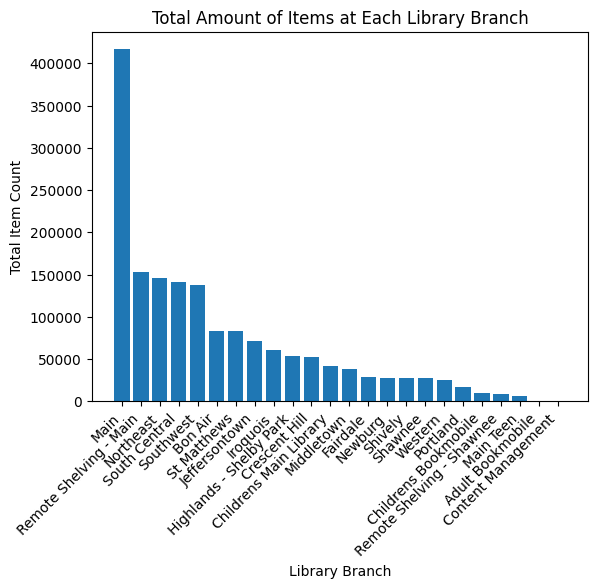

In [29]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

plt.show()

In [30]:
df['ItemLocation'] = df['ItemLocation'].replace('Remote Shelving - Shawnee', 'Shawnee')
df['ItemLocation'] = df['ItemLocation'].replace('Childrens Bookmobile', 'Bookmobile')
df['ItemLocation'] = df['ItemLocation'].replace('Adult Bookmobile', 'Bookmobile')
df['ItemLocation'] = df['ItemLocation'].replace(['Remote Shelving - Main', 'Childrens Main Library', 'Main Teen'], 'Main')

In [31]:
df[df['ItemLocation'] == 'Content Management'].value_counts()

Title                                                                             ItemType  ItemCollection   ItemLocation        ItemPrice  item_id
Effective phrases for performance appraisals : a guide to successful evaluations  Book      Adult Reference  Content Management  $12.95     717251     1
Introducing RDA : a guide to the basics                                           Book      Adult Reference  Content Management  $45.00     719747     1
The Penguin guide to compact discs and DVDs : Yearbook                            Book      Adult Reference  Content Management  $22.00     386265     1
Name: count, dtype: int64

In [32]:
df['ItemLocation'] = df['ItemLocation'].replace('Content Management', 'Main')

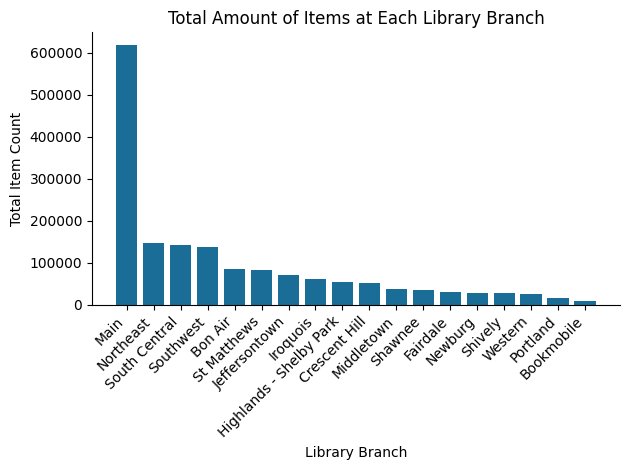

In [33]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalItemAtEachBranchBar.png')
plt.show()

In [34]:
items_per_branch = df.groupby('ItemLocation')['ItemType'].value_counts().reset_index().sort_values(by='count', ascending=True)
items_per_branch

,ItemLocation,ItemType,count
367,Western,Two Dimensional Nonprojected Graphic,1
185,Middletown,Manuscript Material,1
186,Middletown,Printed Cartographic Material,1
187,Middletown,Three Dimensional Object (Artifact),1
188,Middletown,Two Dimensional Nonprojected Graphic,1
...,...,...,...
282,South Central,Book,114719
303,Southwest,Book,118845
207,Northeast,Book,122316
135,Main,Ebook,151681


In [35]:
pivot_df = items_per_branch.pivot(
    index='ItemLocation',
    columns='ItemType',
    values='count'
).fillna(0)

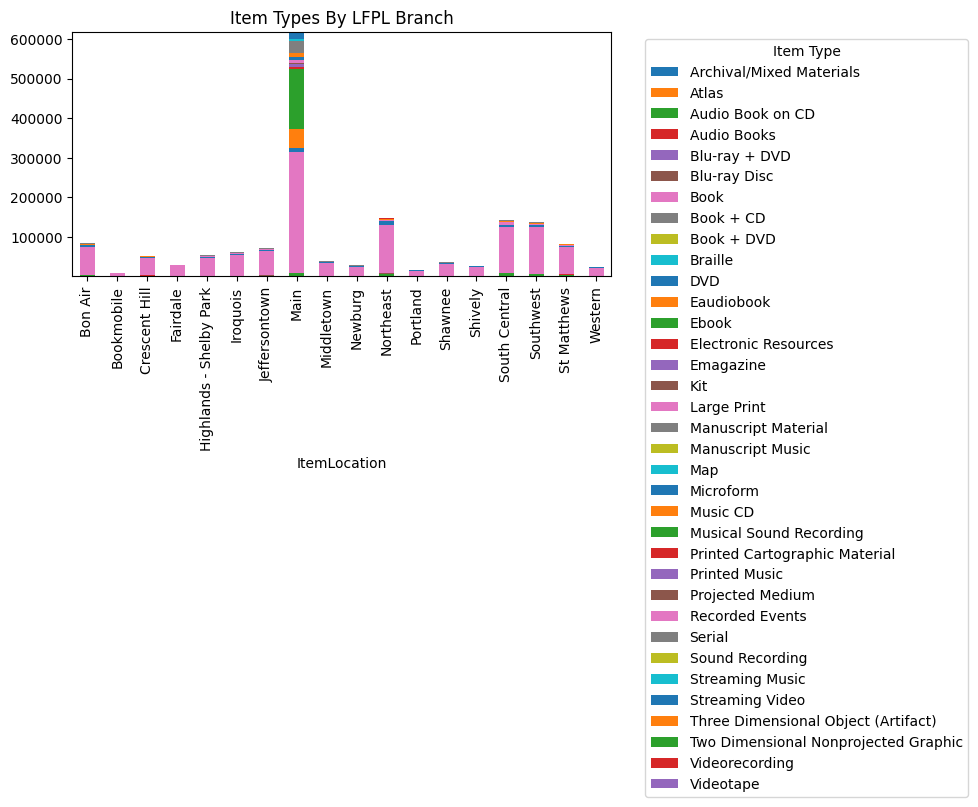

In [36]:
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10,6))

ax.set_title('Item Types By LFPL Branch')

ax.legend(
    title='Item Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

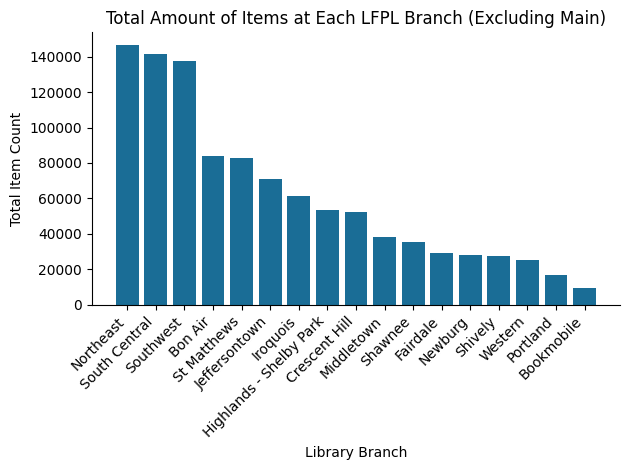

In [37]:
item_count_non_Main = (
    df[df['ItemLocation'] != 'Main']['ItemLocation']
    .value_counts())


plt.bar(item_count_non_Main.index, item_count_non_Main.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each LFPL Branch (Excluding Main)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalItemAtEachBranchExceptMainBar.png')
plt.show()

In [38]:
df.ItemType.unique()

array(['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', 'Kit',
       'Eaudiobook', 'Atlas', 'Emagazine', 'Book + DVD', 'Videorecording',
       'Musical Sound Recording', 'Manuscript Material', 'Large Print',
       'Audio Books', 'Printed Music', 'Book + CD', 'Streaming Video',
       'Sound Recording', 'Braille', 'Serial',
       'Three Dimensional Object (Artifact)', 'Microform',
       'Electronic Resources', 'Blu-ray Disc', 'Recorded Events',
       'Streaming Music', 'Two Dimensional Nonprojected Graphic', 'Map',
       'Printed Cartographic Material', 'Videotape',
       'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music',
       'Blu-ray + DVD'], dtype=object)

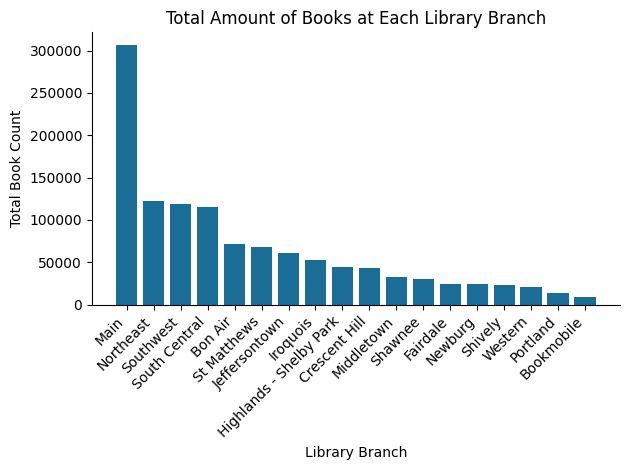

In [39]:
book_itemtype = df[df['ItemType'] == 'Book']
book_count = book_itemtype.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
book_count

plt.bar(book_count.index, book_count.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Book Count')
plt.title('Total Amount of Books at Each Library Branch')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalBooksAtEachBranchBar.png')
plt.show()

## EDA Plots (Geographic Coverage)
Are there areas in Louisville that are underserved in regard to the library?
- A Pin Map is a helpful visual when looking at how the library branches impact the geography of the Louisville area. A light grey background was chosen in order to highlight the smaller libraries with the lighter orange pins. The orange cmap selection allowed the pins to be more visible.
- The Main branch has the largest collection items, which makes sense as it is the oldest branch and also holds ownership over many of the electronic items.
- The Bookmobile location was not included as it does not have a set geographic location.

In [40]:
import geopandas as gpd
import matplotlib.patheffects as pe


In [75]:
lfpl_loc = gpd.read_file("../data/Raw/Louisville_KY_Free_Public_Libraries/Louisville_KY_Free_Public_Libraries.shp")
inventory = pd.read_csv('../data/Clean/clean_lfpl_inventory.csv')
zipcodes = gpd.read_file("../data/Raw/Jefferson_County_KY_ZIP_Codes/Jefferson_County_KY_ZIP_Codes.shp")

In [76]:
book_itemtype = inventory[inventory['item_type'] == 'Book']
book_count = book_itemtype.groupby('item_location').size().reset_index(name='books')

In [78]:
book_count = book_count[book_count["item_location"] != "Bookmobile"]
book_count


,item_location,books
0,Bon Air,72029
2,Crescent Hill,43156
3,Fairdale,24385
4,Highlands - Shelby Park,44265
5,Iroquois,52738
6,Jeffersontown,61113
7,Main,306286
8,Middletown,32281
9,Newburg,23742
10,Northeast,122316


In [95]:
import importlib
import utils

importlib.reload(utils)
    


<module 'utils' from '/Users/brittanyloder/Projects/Capstone/notebook/utils.py'>

In [96]:
utils.name_fix(book_count, 'item_location', lfpl_loc, 'LFPL_NAME')

In [97]:
book_count_map = lfpl_loc.merge(book_count, left_on="LFPL_NAME", right_on="item_location")

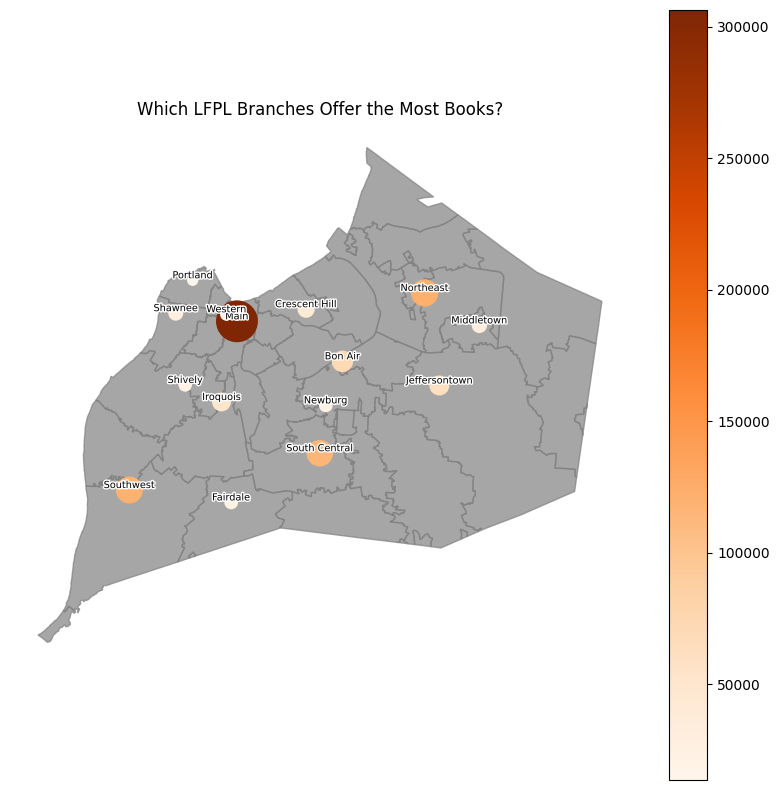

In [98]:
utils.lfpl_map(zipcodes, book_count_map, 'books', "Which LFPL Branches Offer the Most Books?", pe, plt, '../plots/TotalBooksPinMap.png')

## EDA (Comparisons within the Collection)
- A simple pie chart shows a comparison of LFPL Ebook versus Physical Book holdings.
- Heatmaps were used to show how the different item collections were disbursed across the different branches. They highlight some interesting aspects of certain branches such as the teens' collection is more spread out more among the branches than the children's collection and the items labeled as 'Kentucky History' are mostly housed at the Main branch, which highlights its use an archive.

In [99]:
df.ItemType.unique()

AttributeError: 'DataFrame' object has no attribute 'ItemType'

In [ ]:
ebooks = df[df['ItemType'].isin(['Ebook'])]

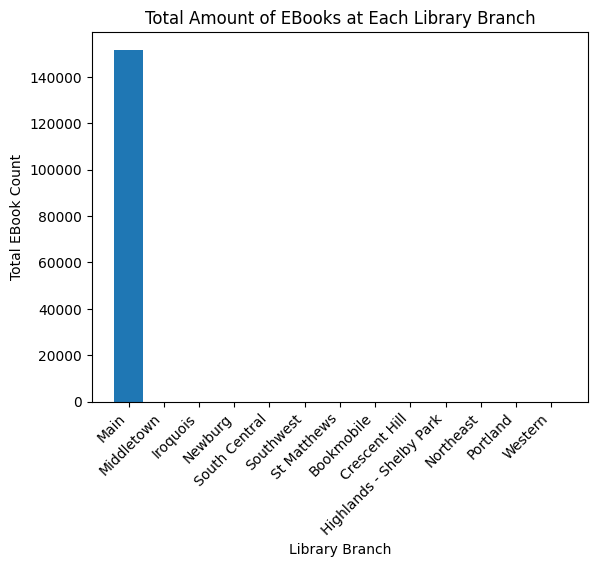

In [ ]:
ebook_count = ebooks.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
ebook_count

plt.bar(ebook_count.index, ebook_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total EBook Count')
plt.title('Total Amount of EBooks at Each Library Branch')

plt.show()

In [ ]:
ebook_len = len(ebooks.value_counts())

In [ ]:
book_len = len(df[df['ItemType'] == 'Book'].value_counts())

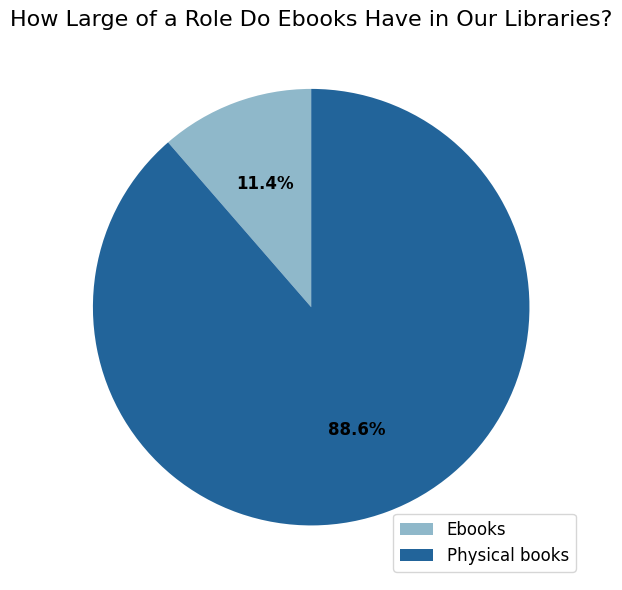

In [ ]:
plt.figure(figsize=(6,6))
plt.pie(
    [ebook_len, book_len],
    labels=None,
    startangle=90,
    colors=["#8fb8caff", "#22649aff"],
    autopct='%1.1f%%',
    textprops={'fontsize' : 12, 'weight': 'bold'})

plt.title('How Large of a Role Do Ebooks Have in Our Libraries?', fontsize=16)
plt.legend(
    labels = ['Ebooks', 'Physical books'], fontsize=12,
    loc='lower right'
)


plt.tight_layout()
plt.savefig('../plots/BooksvsEbooksPieChart.png')
plt.show()


In [ ]:
df['ItemCollection'].unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [ ]:
childrens_words = ['Children', 'Preschool', 'Storytime']
pattern = '|'.join(childrens_words)
childrens_df = df[
    df['ItemCollection'].str.contains(pattern, case=False, na=False)
]


In [ ]:
childrens_df_byloc = childrens_df.groupby(['ItemLocation', 'ItemCollection']).size().reset_index(name='count')
childrens_df_byloc


,ItemLocation,ItemCollection,count
0,Bon Air,Children's Audiobook,283
1,Bon Air,Children's Blu-ray,63
2,Bon Air,Children's Board Book,950
3,Bon Air,Children's DVD,660
4,Bon Air,Children's Easy Reader,1194
...,...,...,...
297,Western,Children's Picture Book,1238
298,Western,Children's Picture Paperback,182
299,Western,Children's Reference,37
300,Western,Preschool Picture Book,1450


In [ ]:
heatmap_data = childrens_df_byloc.pivot(
    index='ItemLocation',
    columns='ItemCollection',
    values='count'
).fillna(0)

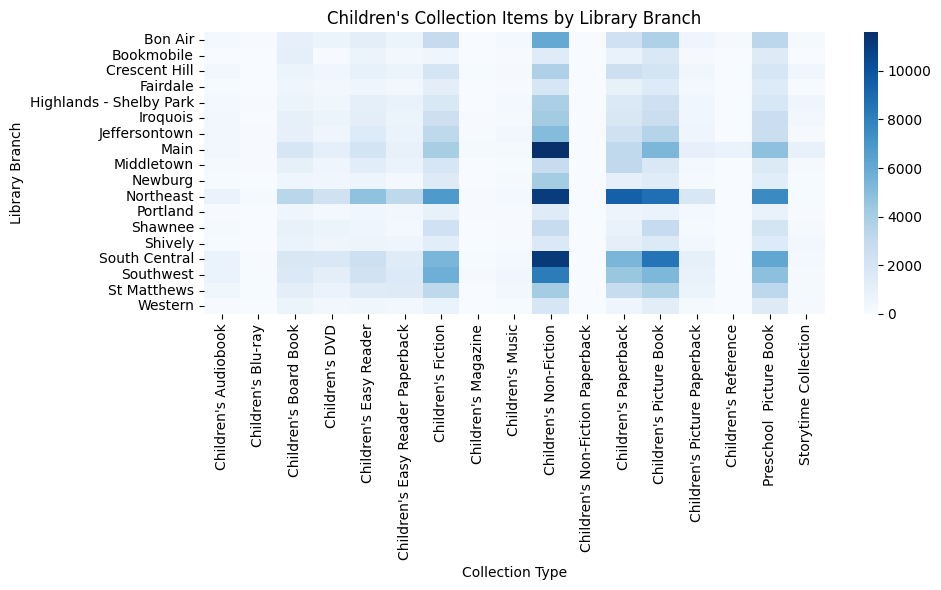

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Children's Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/ChildrensCollectionHeatMap.png')
plt.show()

In [ ]:
teen_words = ['Teen', 'College']
pattern = '|'.join(teen_words)
teens_df = df[
    df['ItemCollection'].str.contains(pattern, case=False, na=False)]

In [ ]:
teens_df_byloc = teens_df.groupby(['ItemLocation', 'ItemCollection']).size().reset_index(name='count')
teens_df_byloc

,ItemLocation,ItemCollection,count
0,Bon Air,Older Teen Fiction,1170
1,Bon Air,Older Teen Paperback,2
2,Bon Air,OlderTeen Audiobook,63
3,Bon Air,Teen Non-Fiction,1318
4,Bon Air,Younger Teen Audiobook,85
...,...,...,...
133,Western,Teen Non-Fiction,777
134,Western,Teen Reference,1
135,Western,Younger Teen Audiobook,21
136,Western,Younger Teen Fiction,298


In [ ]:
heatmap_data = teens_df_byloc.pivot(
    index='ItemLocation',
    columns='ItemCollection',
    values='count'
).fillna(0)

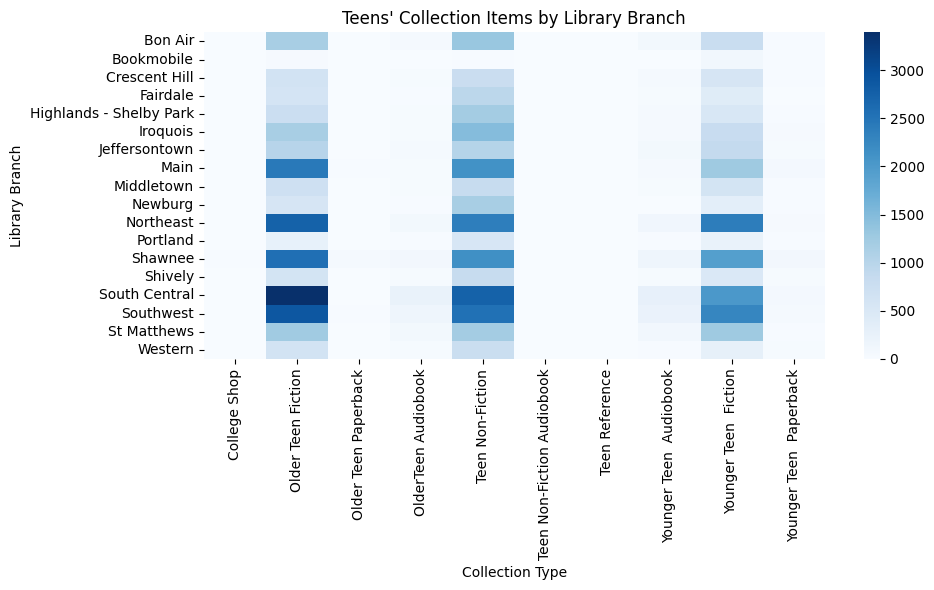

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Teens' Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/TeensCollectionHeatMap.png')
plt.show()

In [ ]:
adult_words = ['Adult', 'ELL', 'Mystery', 'Science', 'Western', 'International', 'Kentucky', 'Natural', 'Oversize','Holiday', 'Urban', 'Bestsellers', 'Large', 'Caldecott/Newberry', 'Government', 'Telereference', 'Big', 'Magazines']
pattern = '|'.join(adult_words)
adults_df = df[
    df['ItemCollection'].str.contains(pattern, case=False, na=False)]

In [ ]:
adults_df_byloc = adults_df.groupby(['ItemLocation', 'ItemCollection']).size().reset_index(name='count')
adults_df_byloc

,ItemLocation,ItemCollection,count
0,Bon Air,Adult Audiobook,2496
1,Bon Air,Adult Blu-Ray,156
2,Bon Air,Adult DVD,2714
3,Bon Air,Adult Fiction,13533
4,Bon Air,Adult Non-Fiction,19982
...,...,...,...
338,Western,Mystery,324
339,Western,Oversize,23
340,Western,Science Fiction,68
341,Western,Urban Fiction,725


In [ ]:
heatmap_data = adults_df_byloc.pivot(
    index='ItemLocation',
    columns='ItemCollection',
    values='count'
).fillna(0)

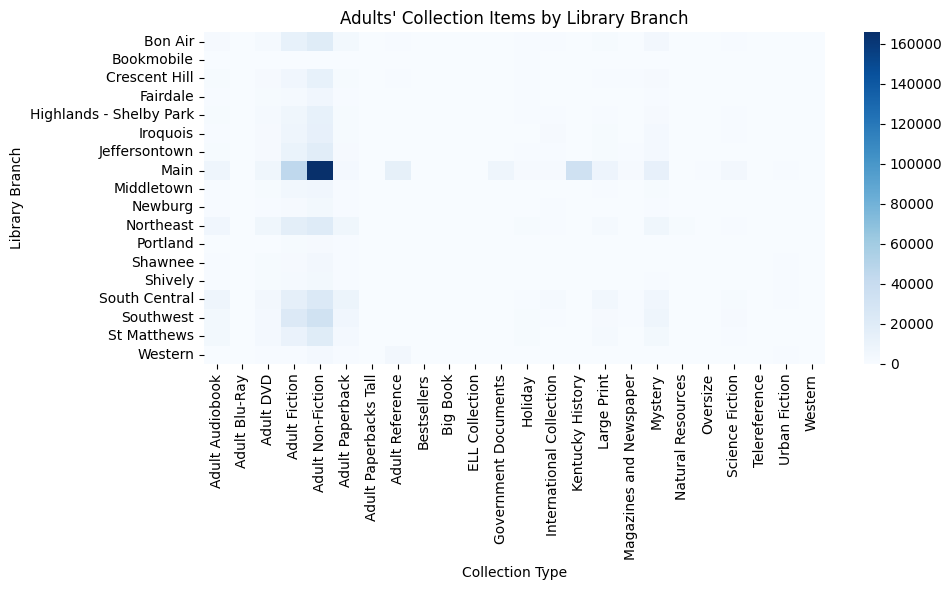

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Adults' Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/AdultsCollectionHeatMap.png')
plt.show()

In [ ]:
df.columns

Index(['Title', 'ItemType', 'ItemCollection', 'ItemLocation', 'ItemPrice',
       'item_id'],
      dtype='object')

In [ ]:
df = df.rename(columns={'Title':'title', 'ItemType':'item_type', 'ItemCollection': 'item_collection', 'ItemLocation':'item_location', 'ItemPrice':'item_price'})

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1657554 entries, 0 to 1657554
Data columns (total 6 columns):
 #   Column           Non-Null Count    Dtype 
---  ------           --------------    ----- 
 0   title            1657554 non-null  object
 1   item_type        1657554 non-null  object
 2   item_collection  1657350 non-null  object
 3   item_location    1657554 non-null  object
 4   item_price       1657554 non-null  object
 5   item_id          1657554 non-null  int64 
dtypes: int64(1), object(5)
memory usage: 88.5+ MB


In [ ]:
df.to_csv('../data/Clean/clean_lfpl_inventory.csv', index=False)